In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, Xception, EfficientNetV2S, VGG16
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import classification_report
import warnings
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score
)
import seaborn as sns
warnings.filterwarnings("ignore")

## Load dataset
dataset contains pf header info

This dataset contains headers of 2157 binary executable samples comprising 1134 legitimate software (goodware) and 1023 ransomware, grouped into 25 ransomware families. The dataset was retrieved by extracting raw information of the PE header (first 1024 bytes).

The CSV file columns are sample ID, filename, target class (GR), family ID, and numerical columns from 0 to 1023, as
follows:


	|   GR      | 	ID	     | 	filename   	| GR |  family	| 	0 - 1023
    |  Goodware | 10000 to 11133 | Their name.exe	 | 0  |  0		 | Numerical features ranging from 0 to 255
    | Ransomware| 20000 to 21022 | Their SHA-256 hash | 1  | 25 family IDs	| Numerical features ranging from 0 to 255	|

Family IDs:
- Avaddon			1
- Babuk			2
- Blackmatter		3
- Conti			4
- Darkside			5
- Dharma			6
- Doppelpaymer	7
- Exorcist			8
- Gandcrab		9
- Lockbit			10
- Makop			11
- Maze			12
- Mountlocker		13
- Nefilim			14
- Netwalker		15
- Phobos			16
- Pysa				17
- Ragnarok		18
- RansomeXX		19
- Revil			20
- Ryuk			21
- Stop				22
- Thanos			23
- Wastedlocker		24
- Zeppelin			25

In [2]:
df = pd.read_csv('Ransomware_headers.csv')

In [3]:
# preview data
df.head()

,ID,filename,GR,family,0,1,2,3,4,5,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,10000,2XClient_12.0_build_2193.paf.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1,10001,7-ZipPortable_21.07.paf.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
2,10002,ARP.EXE,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
3,10003,AccountsControlHost.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
4,10004,ActionUriServer.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# PE Header 1024
df.iloc[:, 4:]

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
3,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
4,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2152,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2153,77,90,80,0,2,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2154,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2155,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.sample(9,random_state=42)

,ID,filename,GR,family,0,1,2,3,4,5,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
746,10746,curl.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1677,20543,b227fa0485e34511627a8a4a7d3f1abb6231517be62d02...,1,14,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1858,20724,9706a97ffa43a0258571def8912dc2b8bf1ee207676052...,1,18,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1657,20523,0bafde9b22d7147de8fdb852bcd529b1730acddc9eb713...,1,14,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
479,10479,SensorDataService.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1730,20596,b96ee4a55d59836de7851f99a18324c6aa8bc223fb581f...,1,15,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1452,20318,bf6e5f9d060ebc5bb70144ca6e795bfc249c6590ab9f45...,1,8,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
905,10905,net1.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
605,10605,WallpaperHost.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0


### Plot sample images

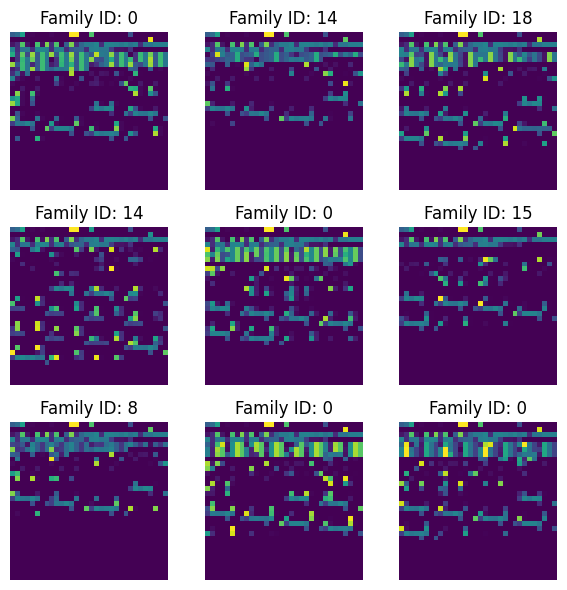

In [6]:
samp  = df.sample(9,random_state=42)
# Convert the numerical columns to color images
samp_images = samp.iloc[:, 4:].values.reshape(-1, 32, 32,1)
# Normalize the image values to [0, 1]
samp_images = samp_images / 255.0

# Create a new figure and plot the images
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

# Flatten the axes array to make it easier to iterate over
axes = axes.flatten()

# Iterate over each image and plot it
for i in range(len(axes)):
    ax = axes[i]
    ax.imshow(samp_images[i], cmap='viridis')  # Assuming grayscale images
    ax.axis('off')  # Turn off axis labels
    ax.set_title(f'Family ID: {samp.iloc[i, 3]}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Convert to colored and Split data

In [7]:
# Split the data into training and validation sets (70% for training, 20% for validation, 10% for test)
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(val_df, test_size=1/3, random_state=42)

# Convert the numerical columns to image
train_images = train_df.iloc[:, 4:].values.reshape(-1, 32, 32,1)
val_images = val_df.iloc[:, 4:].values.reshape(-1, 32, 32,1)
test_images = test_df.iloc[:, 4:].values.reshape(-1, 32, 32,1)

# Normalize the image values to [0, 1]
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

# Convert the numerical columns to color images
train_images = np.repeat(train_images, 3, axis=3)
val_images = np.repeat(val_images, 3, axis=3)
test_images = np.repeat(test_images, 3, axis=3)

In [8]:
# Reshape each image in train_images to (256, 256, 3)
train_images = tf.image.resize(train_images, (256, 256))

# Reshape each image in val_images to (256, 256, 3)
val_images = tf.image.resize(val_images, (256, 256))

# Reshape each image in test_images to (256, 256, 3)
test_images = tf.image.resize(test_images, (256, 256))

## Build Resnet model for Goodware and randsomeware detection

In [9]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [10]:
# Define the ResNet model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
model.fit(train_images, train_labels, epochs=30, validation_data=(val_images, val_labels))

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.8491 - loss: 0.3430 - val_accuracy: 0.6574 - val_loss: 0.6871
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.8355 - loss: 0.3815 - val_accuracy: 0.7801 - val_loss: 0.5609
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.8941 - loss: 0.2845 - val_accuracy: 0.9051 - val_loss: 0.2553
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.8848 - loss: 0.2769 - val_accuracy: 0.8796 - val_loss: 0.3258
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.8985 - loss: 0.2787 - val_accuracy: 0.4653 - val_loss: 2.3413
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.7298 - loss: 0.7541 - val_accuracy: 0.8866 - val_loss: 0.2868
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.8907 - loss: 0.2775 - val_accuracy: 0.8981 - val_loss: 0.2549
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.9055 - loss: 0.2413 - val_accuracy: 0.7199 - v

In [16]:
y_pred = model.predict(test_images)

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step


In [17]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.81      0.97      0.88       117
 Ransomeware       0.95      0.74      0.83        99

    accuracy                           0.86       216
   macro avg       0.88      0.85      0.86       216
weighted avg       0.87      0.86      0.86       216



In [18]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.81      0.97      0.88       117
 Ransomeware       0.95      0.74      0.83        99

    accuracy                           0.86       216
   macro avg       0.88      0.85      0.86       216
weighted avg       0.87      0.86      0.86       216

Confusion Matrix: 
[[113   4]
 [ 26  73]]
Precision: 0.9481
Recall: 0.7374
Accuracy: 0.8611
FN Rate: 0.2626
FP Rate: 0.0342
F-measure: 0.8295
Error Rate: 0.1389
MCC: 0.7315
Kappa: 0.7154
AUC-ROC: 0.9483


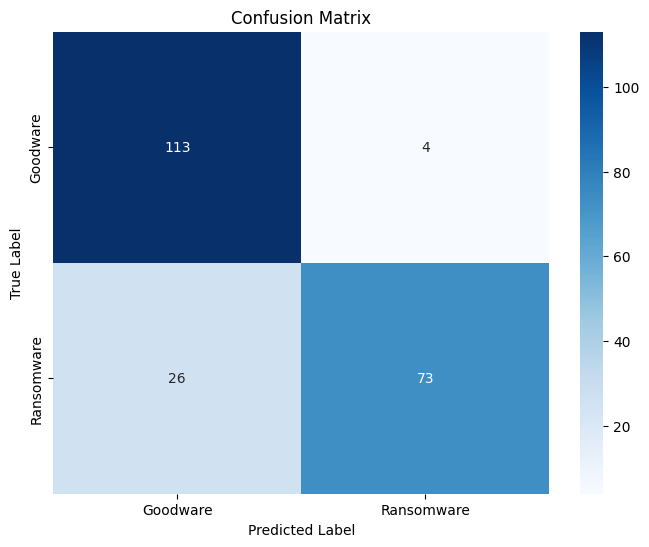

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [20]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

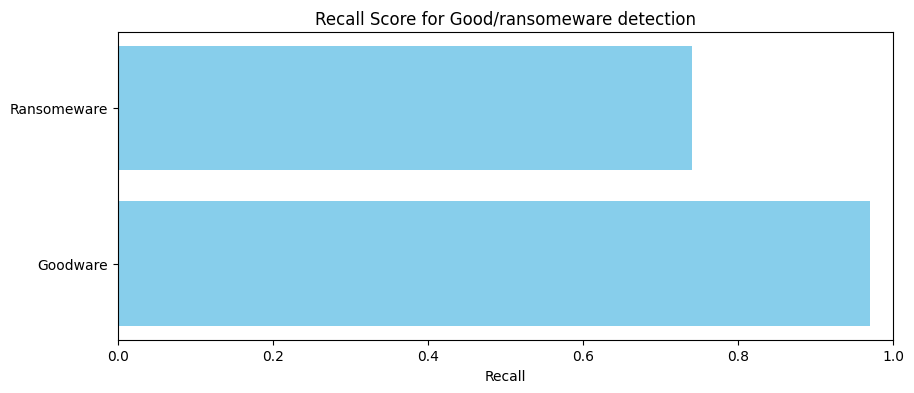

In [21]:
plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='skyblue')
plt.xlabel('Recall')
plt.title('Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build Xception model for Goodware/Ransomeware detection

In [22]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [23]:
# Define the ResNet model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_xception = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [24]:
# Compile the model
model_xception.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
# train model
model_xception.fit(train_images, train_labels, epochs=25, validation_data=(val_images, val_labels))

Epoch 1/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.6589 - loss: 2.8834 - val_accuracy: 0.8889 - val_loss: 0.2900
Epoch 2/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 167s 4s/step - accuracy: 0.8844 - loss: 0.2973 - val_accuracy: 0.8542 - val_loss: 0.3413
Epoch 3/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.9015 - loss: 0.2495 - val_accuracy: 0.9306 - val_loss: 0.1886
Epoch 4/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.9514 - loss: 0.1332 - val_accuracy: 0.9144 - val_loss: 0.1961
Epoch 5/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 168s 4s/step - accuracy: 0.9651 - loss: 0.1016 - val_accuracy: 0.9398 - val_loss: 0.1506
Epoch 6/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 169s 4s/step - accuracy: 0.9862 - loss: 0.0635 - val_accuracy: 0.9444 - val_loss: 0.1307
Epoch 7/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.9922 - loss: 0.0360 - val_accuracy: 0.9421 - val_loss: 0.1376
Epoch 8/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.9905 - loss: 0.0327 - val_accuracy: 0.9560 - v

In [26]:
# Evaluate the model on the validation set
y_pred = model_xception.predict(test_images)

7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step


In [27]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.94      0.97      0.95       117
 Ransomeware       0.96      0.93      0.94        99

    accuracy                           0.95       216
   macro avg       0.95      0.95      0.95       216
weighted avg       0.95      0.95      0.95       216



In [28]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.94      0.97      0.95       117
 Ransomeware       0.96      0.93      0.94        99

    accuracy                           0.95       216
   macro avg       0.95      0.95      0.95       216
weighted avg       0.95      0.95      0.95       216

Confusion Matrix: 
[[113   4]
 [  7  92]]
Precision: 0.9583
Recall: 0.9293
Accuracy: 0.9491
FN Rate: 0.0707
FP Rate: 0.0342
F-measure: 0.9436
Error Rate: 0.0509
MCC: 0.8975
Kappa: 0.8972
AUC-ROC: 0.9841


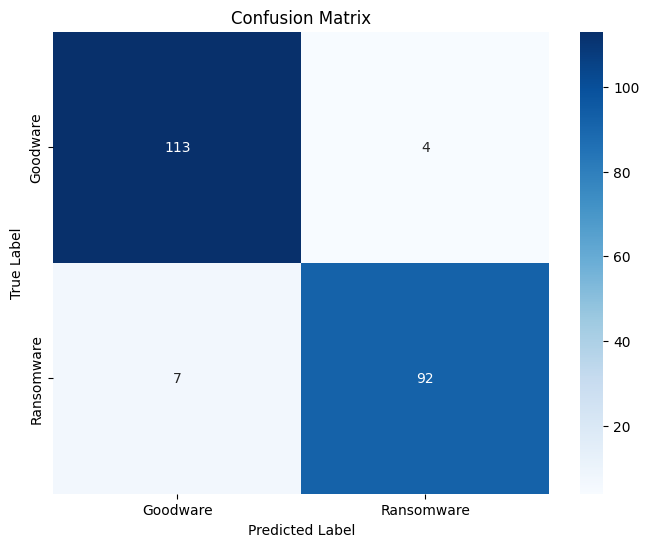

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

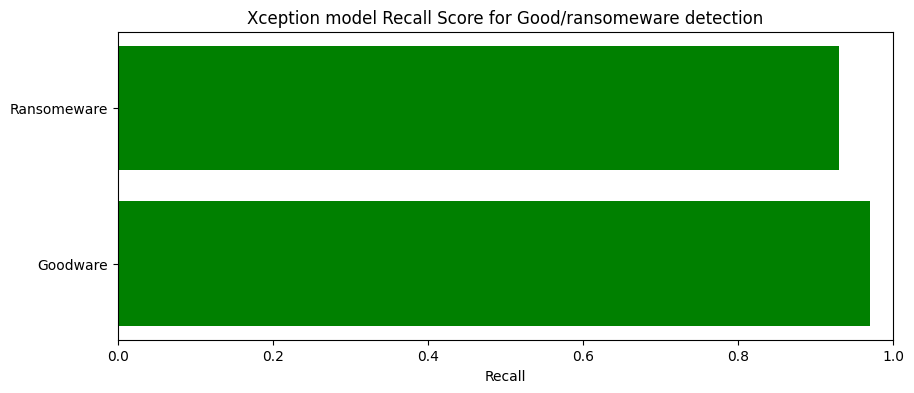

In [30]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='green')
plt.xlabel('Recall')
plt.title('Xception model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build VGG16 model for Goodware/Ransomeware detection

In [31]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [32]:
# Define the ResNet model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_VGG = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [33]:
# Compile the model
model_VGG.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [34]:
# train model
model_VGG.fit(train_images, train_labels, epochs=20, validation_data=(val_images, val_labels))

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 387s 8s/step - accuracy: 0.6457 - loss: 1.0200 - val_accuracy: 0.9097 - val_loss: 0.2576
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 387s 8s/step - accuracy: 0.8833 - loss: 0.2748 - val_accuracy: 0.8403 - val_loss: 0.3581
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 388s 8s/step - accuracy: 0.9079 - loss: 0.2363 - val_accuracy: 0.9120 - val_loss: 0.2083
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 388s 8s/step - accuracy: 0.9441 - loss: 0.1543 - val_accuracy: 0.9282 - val_loss: 0.1832
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 388s 8s/step - accuracy: 0.9663 - loss: 0.1002 - val_accuracy: 0.9375 - val_loss: 0.1605
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 388s 8s/step - accuracy: 0.9636 - loss: 0.0985 - val_accuracy: 0.9282 - val_loss: 0.1828
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 400s 8s/step - accuracy: 0.9594 - loss: 0.0940 - val_accuracy: 0.8866 - val_loss: 0.2988
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 413s 9s/step - accuracy: 0.9695 - loss: 0.0817 - val_accuracy: 0.9491 - v

In [37]:
# Evaluate the model on the validation set
y_pred = model_VGG.predict(test_images)

7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step


In [38]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.92      0.94      0.93       117
 Ransomeware       0.93      0.90      0.91        99

    accuracy                           0.92       216
   macro avg       0.92      0.92      0.92       216
weighted avg       0.92      0.92      0.92       216



In [39]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.92      0.94      0.93       117
 Ransomeware       0.93      0.90      0.91        99

    accuracy                           0.92       216
   macro avg       0.92      0.92      0.92       216
weighted avg       0.92      0.92      0.92       216

Confusion Matrix: 
[[110   7]
 [ 10  89]]
Precision: 0.9271
Recall: 0.8990
Accuracy: 0.9213
FN Rate: 0.1010
FP Rate: 0.0598
F-measure: 0.9128
Error Rate: 0.0787
MCC: 0.8415
Kappa: 0.8411
AUC-ROC: 0.9825


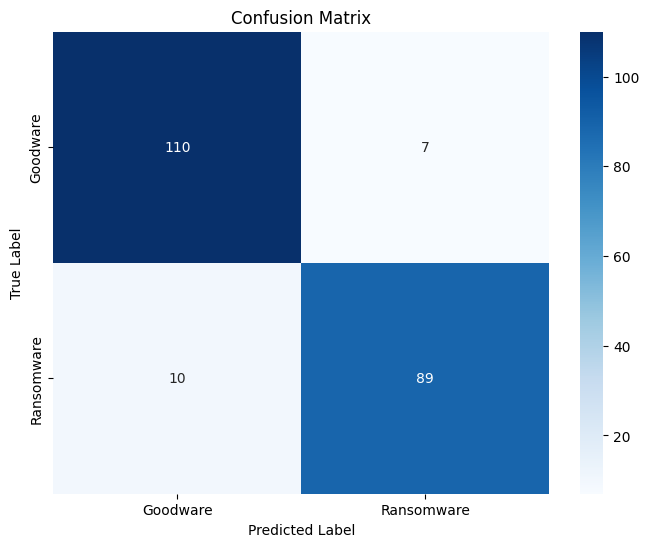

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

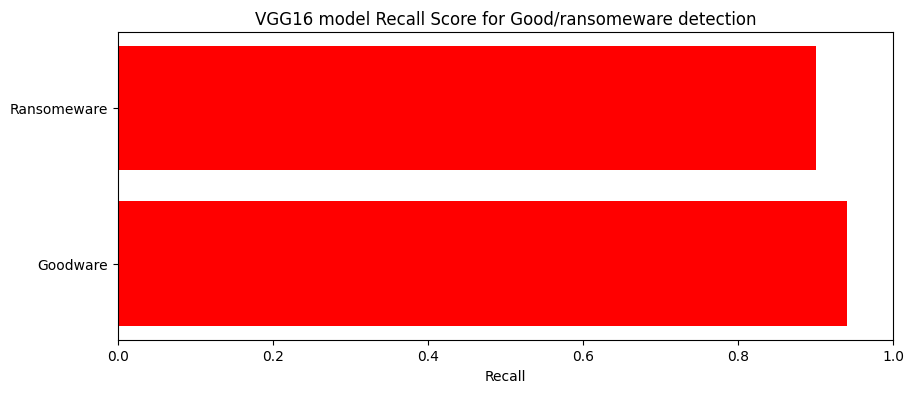

In [41]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='red')
plt.xlabel('Recall')
plt.title('VGG16 model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()